In [ ]:
# === CONFIGURATION — edit paths here ===
SCHEDULER_DIR = '/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/scheduler'
METRICS_DIR   = SCHEDULER_DIR + '/metrics_csv'
NETCDF_DIR    = SCHEDULER_DIR + '/netcdf_pressure_interp'
# Archive (read-only): all outputs are backed up to:
#   /glade/campaign/cisl/aiml/credit/models/sdl_camulator/era5_ensemble_2022


In [7]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import glob
import warnings
warnings.filterwarnings('ignore')


def compute_latitude_weights(latitudes):
    """
    Compute cosine latitude weights (NOT normalized)
    Matches the original code behavior
    """
    weights = np.cos(np.deg2rad(latitudes))
    return weights


def compute_crps_ensemble(ensemble, truth):
    """
    Compute CRPS for ensemble forecast
    ensemble: [n_members, lat, lon]
    truth: [lat, lon]
    Returns: scalar CRPS value
    """
    n_members = ensemble.shape[0]
    
    # Sort ensemble members
    sorted_ens = np.sort(ensemble, axis=0)
    
    # Term 1: mean absolute error
    abs_diff = np.abs(ensemble - truth[np.newaxis, :, :])
    term1 = np.mean(abs_diff, axis=0)
    
    # Term 2: mean absolute difference between members
    term2 = 0.0
    count = 0
    for i in range(n_members):
        for j in range(i + 1, n_members):
            term2 += np.abs(ensemble[i] - ensemble[j])
            count += 1
    term2 = term2 / count if count > 0 else 0.0
    
    crps = term1 - 0.5 * term2
    return crps


def compute_rank_histogram(ensemble, truth):
    """
    Compute rank histogram counts
    ensemble: [n_members, lat, lon]
    truth: [lat, lon]
    Returns: array of counts of length (n_members + 1)
    """
    n_members = ensemble.shape[0]
    
    # Flatten spatial dimensions
    ensemble_flat = ensemble.reshape(n_members, -1)  # [members, spatial_points]
    truth_flat = truth.flatten()  # [spatial_points]
    
    # Count ranks for each spatial point
    rank_counts = np.zeros(n_members + 1, dtype=np.int64)
    
    for i in range(ensemble_flat.shape[1]):
        ens_values = ensemble_flat[:, i]
        truth_value = truth_flat[i]
        
        # Count how many ensemble members are less than truth
        rank = np.sum(ens_values < truth_value)
        rank_counts[rank] += 1
    
    return rank_counts


def compute_metrics_for_variable(pred_ens, truth, lat_weights, var_name):
    """
    Compute all metrics for a single variable
    Matches the exact computation from the original LatWeightedMetrics class
    
    Parameters:
    -----------
    pred_ens: np.array [n_members, lat, lon]
    truth: np.array [lat, lon]
    lat_weights: np.array [lat]
    var_name: str
    
    Returns:
    --------
    dict with metrics
    """
    n_members = pred_ens.shape[0]
    
    # Expand lat_weights to [lat, 1] for broadcasting
    w_lat = lat_weights[:, np.newaxis]  # [lat, 1]
    
    # Ensemble mean
    pred_mean = pred_ens.mean(axis=0)  # [lat, lon]
    
    # Error
    error = pred_mean - truth  # [lat, lon]
    
    # RMSE - matching original formula exactly
    # Original: torch.mean(torch.sqrt(torch.mean(error**2 * w_lat, dim=(-2, -1))))
    # Since we have no batch dimension, this simplifies to:
    rmse = np.sqrt(np.mean(error**2 * w_lat))
    
    # MSE - matching original formula
    # Original: (error**2 * w_lat).mean()
    mse = np.mean(error**2 * w_lat)
    
    # MAE - matching original formula
    # Original: (torch.abs(error) * w_lat).mean()
    mae = np.mean(np.abs(error) * w_lat)
    
    # Ensemble spread (standard deviation with Bessel's correction)
    # Original: std_dev = torch.std(pred, dim=1) with ddof=1 implicit
    std_dev = pred_ens.std(axis=0, ddof=1)  # [lat, lon]
    # Original: torch.mean(torch.sqrt(torch.mean(std_dev**2 * w_lat, dim=(-2, -1))))
    spread = np.sqrt(np.mean(std_dev**2 * w_lat))
    
    # SSR (Spread-Skill Ratio)
    ssr = spread / (rmse + 1e-7)
    
    # ACC (Anomaly Correlation Coefficient)
    # Original uses torch.mean() which is global mean
    pred_mean_prime = pred_mean - np.mean(pred_mean)
    truth_prime = truth - np.mean(truth)
    
    # Original: torch.sum(w_lat * pred_prime * y_prime) / denominator
    numerator = np.sum(w_lat * pred_mean_prime * truth_prime)
    denominator = np.sqrt(
        np.sum(w_lat * pred_mean_prime**2) * 
        np.sum(w_lat * truth_prime**2)
    ) + 1e-7
    acc = numerator / denominator
    
    # CRPS (weighted like RMSE)
    crps_field = compute_crps_ensemble(pred_ens, truth)  # [lat, lon]
    crps = np.sqrt(np.mean(crps_field**2 * w_lat))
    
    # Rank histogram
    rank_counts = compute_rank_histogram(pred_ens, truth)
    
    metrics = {
        'variable': var_name,
        'rmse': rmse,
        'mse': mse,
        'mae': mae,
        'spread': spread,
        'ssr': ssr,
        'acc': acc,
        'crps': crps,
    }
    
    # Add rank counts as separate columns
    for i, count in enumerate(rank_counts):
        metrics[f'rank_{i}'] = count
    
    return metrics


def process_one_forecast(forecast_date, netcdf_dir, era5_zarr_path, lat_weights_file, output_dir):
    """
    Process one forecast initialization time (all 60 lead times)
    
    Parameters:
    -----------
    forecast_date: str or datetime
        Forecast initialization date (e.g., '2022-01-01')
    netcdf_dir: str or Path
        Base directory containing netcdf files
    era5_zarr_path: str or Path
        Path to ERA5 zarr file
    lat_weights_file: str or Path
        Path to latitude weights file
    output_dir: str or Path
        Directory to save CSV output
    """
    if isinstance(forecast_date, str):
        forecast_date = datetime.strptime(forecast_date, '%Y-%m-%d')
    
    forecast_str = forecast_date.strftime('%Y-%m-%dT00Z')
    print(f"Processing forecast: {forecast_str}")
    
    # Load latitude weights
    latlons = xr.open_dataset(lat_weights_file).load()
    latitudes = latlons.latitude.values
    lat_weights = compute_latitude_weights(latitudes)
    
    # Load ERA5 data for 2022
    print("Loading ERA5 data...")
    era5 = xr.open_zarr(era5_zarr_path)
    
    # Determine variables from first prediction file
    first_file = Path(netcdf_dir) / forecast_str / f'pred_{forecast_str}_006.nc'
    if not first_file.exists():
        print(f"Warning: {first_file} does not exist. Skipping.")
        return
    
    sample_pred = xr.open_dataset(first_file)
    
    # Get all variables (excluding coordinates and dimensions)
    pred_vars = [v for v in sample_pred.data_vars if v not in ['time', 'level', 'latitude', 'longitude', 'ensemble_member_label', 'forecast_hour']]
    
    print(f"Found {len(pred_vars)} variables: {pred_vars}")
    
    all_metrics = []
    
    # Loop through lead times (6, 12, 18, ..., 360 hours)
    lead_times = range(6, 361, 6)
    
    for lead_hour in lead_times:
        print(f"  Lead time: {lead_hour:03d} hours", end='\r')
        
        # Valid time = forecast init + lead time
        valid_time = forecast_date + timedelta(hours=lead_hour)
        
        # Load prediction file
        pred_file = Path(netcdf_dir) / forecast_str / f'pred_{forecast_str}_{lead_hour:03d}.nc'
        
        if not pred_file.exists():
            print(f"\n  Warning: {pred_file} does not exist. Skipping lead time {lead_hour}")
            continue
        
        pred_ds = xr.open_dataset(pred_file)
        
        # Select ERA5 data at valid time
        try:
            era5_valid = era5.sel(time=valid_time, method='nearest')
        except:
            print(f"\n  Warning: Could not find ERA5 data for {valid_time}. Skipping.")
            continue
        
        # Process each variable
        for var in pred_vars:
            if var not in pred_ds:
                continue
            
            pred_data = pred_ds[var].values  # [ensemble, time, ...]
            
            # Squeeze out time dimension if present
            if pred_data.shape[1] == 1:  # [ensemble, 1, ...]
                pred_data = pred_data[:, 0, ...]  # [ensemble, ...]
            
            # Try to find matching variable in ERA5
            era5_var = None
            if var in era5_valid:
                era5_var = var
            elif var.lower() in era5_valid:
                era5_var = var.lower()
            elif var.upper() in era5_valid:
                era5_var = var.upper()
            
            if era5_var is None:
                # Try common variants
                var_lower = var.lower()
                if var_lower == 'sp':
                    era5_var = 'SP' if 'SP' in era5_valid else None
                elif var_lower == 't2m':
                    era5_var = 't2m' if 't2m' in era5_valid else None
                
            if era5_var is None:
                print(f"\n  Warning: Could not find ERA5 variable matching {var}")
                continue
            
            era5_data = era5_valid[era5_var].values
            
            # Squeeze ERA5 time dimension if present
            if era5_data.ndim > 2 and era5_data.shape[0] == 1:
                era5_data = era5_data[0, ...]
            
            # Handle multi-level variables
            if pred_data.ndim == 4:  # [ensemble, level, lat, lon]
                n_levels = pred_data.shape[1]
                
                for lev_idx in range(n_levels):
                    pred_lev = pred_data[:, lev_idx, :, :]  # [ensemble, lat, lon]
                    
                    # Get corresponding ERA5 level
                    if era5_data.ndim == 3:  # [level, lat, lon]
                        era5_lev = era5_data[lev_idx, :, :]
                    elif era5_data.ndim == 2:  # [lat, lon] - single level
                        era5_lev = era5_data
                    else:
                        print(f"\n  Warning: Unexpected ERA5 shape for {var}: {era5_data.shape}")
                        continue
                    
                    var_name = f"{var}_{lev_idx}"
                    
                    metrics = compute_metrics_for_variable(pred_lev, era5_lev, lat_weights, var_name)
                    metrics['forecast_date'] = forecast_str
                    metrics['lead_time'] = lead_hour
                    all_metrics.append(metrics)
            
            elif pred_data.ndim == 3:  # [ensemble, lat, lon]
                # Ensure ERA5 is 2D
                if era5_data.ndim == 3:
                    era5_data = era5_data[0, :, :] if era5_data.shape[0] == 1 else era5_data
                
                metrics = compute_metrics_for_variable(pred_data, era5_data, lat_weights, var)
                metrics['forecast_date'] = forecast_str
                metrics['lead_time'] = lead_hour
                all_metrics.append(metrics)
            
            else:
                print(f"\n  Warning: Unexpected shape for {var}: {pred_data.shape}")
        
        pred_ds.close()
    
    print(f"\n  Processed {len(all_metrics)} variable/level/leadtime combinations")
    
    # Save to CSV
    if len(all_metrics) > 0:
        df = pd.DataFrame(all_metrics)
        
        # Reorder columns
        rank_cols = [c for c in df.columns if c.startswith('rank_')]
        metric_cols = ['forecast_date', 'lead_time', 'variable', 'rmse', 'mse', 'mae', 'spread', 'ssr', 'acc', 'crps']
        df = df[metric_cols + rank_cols]
        
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        output_file = output_dir / f'metrics_{forecast_str}.csv'
        df.to_csv(output_file, index=False)
        print(f"Saved metrics to {output_file}")
    
    sample_pred.close()
    era5.close()


def process_all_forecasts_2022(netcdf_dir, era5_zarr_path, lat_weights_file, output_dir):
    """
    Process all forecasts in 2022 (365 days)
    """
    start_date = datetime(2022, 1, 1)
    
    for day_offset in range(365):
        forecast_date = start_date + timedelta(days=day_offset)
        
        try:
            process_one_forecast(
                forecast_date, 
                netcdf_dir, 
                era5_zarr_path, 
                lat_weights_file, 
                output_dir
            )
        except Exception as e:
            print(f"Error processing {forecast_date}: {e}")
            continue

In [22]:
# def load_all_metrics(metrics_dir):
#     """
#     Load all CSV files and combine into one DataFrame
#     """
#     csv_files = glob.glob(str(Path(metrics_dir) / "metrics_*.csv"))
    
#     print(f"Found {len(csv_files)} CSV files")
    
#     dfs = []
#     for csv_file in csv_files:
#         df = pd.read_csv(csv_file)
#         dfs.append(df)
    
#     combined = pd.concat(dfs, ignore_index=True)
#     print(f"Total rows: {len(combined)}")
    
#     return combined


# def aggregate_metrics_by_lead(df):
#     """
#     Aggregate metrics by variable and lead time
#     Returns a dict: {metric_name: {variable: [values by lead time]}}
#     """
#     # Get all unique variables and lead times
#     variables = df['variable'].unique()
#     lead_times = sorted(df['lead_time'].unique())
    
#     # Metrics to aggregate
#     metric_names = ['crps', 'rmse', 'spread', 'ssr', 'acc', 'mse', 'mae']
    
#     # Get rank columns
#     rank_cols = [c for c in df.columns if c.startswith('rank_')]
#     n_ranks = len(rank_cols)
    
#     aggregated = {}
    
#     for metric in metric_names:
#         aggregated[metric] = {}
#         for var in variables:
#             values = []
#             for lead in lead_times:
#                 subset = df[(df['variable'] == var) & (df['lead_time'] == lead)]
#                 if len(subset) > 0:
#                     values.append(subset[metric].mean())
#                 else:
#                     values.append(np.nan)
#             aggregated[metric][var] = values
    
#     # Aggregate rank histograms
#     aggregated['rank_histogram'] = {}
#     for var in variables:
#         rank_histograms_by_lead = []
#         for lead in lead_times:
#             subset = df[(df['variable'] == var) & (df['lead_time'] == lead)]
#             if len(subset) > 0:
#                 # Sum up all rank counts across all forecasts
#                 rank_counts = subset[rank_cols].sum(axis=0).values
#                 # Normalize to get frequencies
#                 rank_freq = rank_counts / rank_counts.sum() if rank_counts.sum() > 0 else rank_counts
#                 rank_histograms_by_lead.append(rank_freq)
#             else:
#                 rank_histograms_by_lead.append(np.full(n_ranks, np.nan))
#         aggregated['rank_histogram'][var] = rank_histograms_by_lead
    
#     aggregated['lead_times'] = lead_times
#     aggregated['variables'] = variables
    
#     return aggregated


def _load_single_csv(csv_file):
    """Helper function to load a single CSV file"""
    return pd.read_csv(csv_file)


def load_all_metrics(metrics_dir, pool=None):
    """
    Load all CSV files and combine into one DataFrame
    
    Parameters
    ----------
    metrics_dir : str or Path
        Directory containing metrics CSV files
    pool : multiprocessing.Pool, optional
        Pool object for parallel processing. If None, runs serially.
    """
    csv_files = glob.glob(str(Path(metrics_dir) / "metrics_*.csv"))
    
    print(f"Found {len(csv_files)} CSV files")
    
    if pool is not None:
        # Parallel loading
        dfs = pool.map(_load_single_csv, csv_files)
    else:
        # Serial loading
        dfs = [pd.read_csv(csv_file) for csv_file in csv_files]
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f"Total rows: {len(combined)}")
    
    return combined


def _aggregate_single_variable(args):
    """
    Helper function to aggregate metrics for a single variable
    
    Parameters
    ----------
    args : tuple
        (df, var, lead_times, metric_names, rank_cols)
    """
    df, var, lead_times, metric_names, rank_cols = args
    
    var_results = {'variable': var}
    
    # Aggregate scalar metrics
    for metric in metric_names:
        values = []
        for lead in lead_times:
            subset = df[(df['variable'] == var) & (df['lead_time'] == lead)]
            if len(subset) > 0:
                values.append(subset[metric].mean())
            else:
                values.append(np.nan)
        var_results[metric] = values
    
    # Aggregate rank histograms
    rank_histograms_by_lead = []
    for lead in lead_times:
        subset = df[(df['variable'] == var) & (df['lead_time'] == lead)]
        if len(subset) > 0:
            rank_counts = subset[rank_cols].sum(axis=0).values
            rank_freq = rank_counts / rank_counts.sum() if rank_counts.sum() > 0 else rank_counts
            rank_histograms_by_lead.append(rank_freq)
        else:
            rank_histograms_by_lead.append(np.full(len(rank_cols), np.nan))
    var_results['rank_histogram'] = rank_histograms_by_lead
    
    return var_results


def aggregate_metrics_by_lead(df, pool=None):
    """
    Aggregate metrics by variable and lead time
    
    Parameters
    ----------
    df : pd.DataFrame
        Combined metrics dataframe
    pool : multiprocessing.Pool, optional
        Pool object for parallel processing. If None, runs serially.
    
    Returns
    -------
    dict
        {metric_name: {variable: [values by lead time]}}
    """
    # Get all unique variables and lead times
    variables = df['variable'].unique()
    lead_times = sorted(df['lead_time'].unique())
    
    # Metrics to aggregate
    metric_names = ['crps', 'rmse', 'spread', 'ssr', 'acc', 'mse', 'mae']
    
    # Get rank columns
    rank_cols = [c for c in df.columns if c.startswith('rank_')]
    
    # Prepare arguments for parallel processing
    args_list = [(df, var, lead_times, metric_names, rank_cols) for var in variables]
    
    if pool is not None:
        # Parallel aggregation
        var_results_list = pool.map(_aggregate_single_variable, args_list)
    else:
        # Serial aggregation
        var_results_list = [_aggregate_single_variable(args) for args in args_list]
    
    # Reorganize results into the expected format
    aggregated = {}
    
    for metric in metric_names:
        aggregated[metric] = {}
        for var_result in var_results_list:
            var = var_result['variable']
            aggregated[metric][var] = var_result[metric]
    
    aggregated['rank_histogram'] = {}
    for var_result in var_results_list:
        var = var_result['variable']
        aggregated['rank_histogram'][var] = var_result['rank_histogram']
    
    aggregated['lead_times'] = lead_times
    aggregated['variables'] = variables
    
    return aggregated


def aggregated_to_csv(aggregated, output_file):
    """
    Convert aggregated metrics dict to a CSV file
    
    Parameters
    ----------
    aggregated : dict
        Output from aggregate_metrics_by_lead()
    output_file : str or Path
        Path to save CSV file
    """
    rows = []
    
    lead_times = aggregated['lead_times']
    variables = aggregated['variables']
    metric_names = ['crps', 'rmse', 'spread', 'ssr', 'acc', 'mse', 'mae']
    
    # Build rows for scalar metrics
    for var in variables:
        for i, lead in enumerate(lead_times):
            row = {
                'variable': var,
                'lead_time': lead
            }
            
            # Add scalar metrics
            for metric in metric_names:
                if metric in aggregated and var in aggregated[metric]:
                    row[metric] = aggregated[metric][var][i]
            
            # Add rank histogram as columns
            if 'rank_histogram' in aggregated and var in aggregated['rank_histogram']:
                rank_hist = aggregated['rank_histogram'][var][i]
                for rank_idx, freq in enumerate(rank_hist):
                    row[f'rank_{rank_idx}'] = freq
            
            rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Reorder columns
    base_cols = ['variable', 'lead_time'] + metric_names
    rank_cols = [c for c in df.columns if c.startswith('rank_')]
    df = df[base_cols + rank_cols]
    
    df.to_csv(output_file, index=False)
    print(f"✅ Saved aggregated metrics to {output_file}")
    
    return df


def plot_ensemble_metrics(aggregated, variables_to_plot, output_file='ensemble_metrics.png'):
    """
    Create the multi-panel plot similar to the FCN3 figure
    
    Parameters:
    -----------
    aggregated: dict from aggregate_metrics_by_lead
    variables_to_plot: list of variable names (e.g., ['msl', 'u10m', 'z500', 't850', 'u850', 'q700'])
    output_file: str, output filename
    """
    n_vars = len(variables_to_plot)
    lead_times = aggregated['lead_times']
    
    # Create figure
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(4, n_vars, figure=fig, hspace=0.35, wspace=0.3)
    
    color = 'green'  # Single model
    
    for col, var_name in enumerate(variables_to_plot):
        # Find matching variable in aggregated data
        # Try exact match first, then case-insensitive
        actual_var = None
        for v in aggregated['variables']:
            if var_name.lower() in v.lower():
                actual_var = v
                break
        
        if actual_var is None:
            print(f"Warning: Variable {var_name} not found in metrics")
            continue
        
        print(f"Plotting {var_name} (matched to {actual_var})")
        
        # Row 1: CRPS
        ax_crps = fig.add_subplot(gs[0, col])
        values = aggregated['crps'][actual_var]
        ax_crps.plot(lead_times, values, color=color, linewidth=2)
        ax_crps.set_xlabel('Lead time (hours)', fontsize=10)
        if col == 0:
            ax_crps.set_ylabel('CRPS', fontsize=11)
        ax_crps.set_title(var_name, fontsize=12)
        ax_crps.grid(True, alpha=0.3)
        
        # Row 2: RMSE
        ax_rmse = fig.add_subplot(gs[1, col])
        values = aggregated['rmse'][actual_var]
        ax_rmse.plot(lead_times, values, color=color, linewidth=2)
        ax_rmse.set_xlabel('Lead time (hours)', fontsize=10)
        if col == 0:
            ax_rmse.set_ylabel('RMSE', fontsize=11)
        ax_rmse.grid(True, alpha=0.3)
        
        # Row 3: SSR
                # Row 3: SSR
        ax_ssr = fig.add_subplot(gs[2, col])
        values = aggregated['ssr'][actual_var]

        # Apply ensemble-size correction
        n_members = len(aggregated['rank_histogram'][actual_var][0])
        correction_factor = (n_members + 1) / (n_members - 1)
        values = np.array(values) * correction_factor

        ax_ssr.plot(lead_times, values, color=color, linewidth=2)
        ax_ssr.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax_ssr.set_xlabel('Lead time (hours)', fontsize=10)
        if col == 0:
            ax_ssr.set_ylabel('SSR', fontsize=11)
        ax_ssr.grid(True, alpha=0.3)
        ax_ssr.set_ylim([0, 1.5])
        
        # Row 4: Rank histogram
        # Show histogram for specific lead times
        ax_rank = fig.add_subplot(gs[3, col])
        
        # Select lead times to show (e.g., 6h, 120h, 240h, 360h)
        lead_indices_to_show = {
            6: ('6 hours', 'purple'),
            120: ('120 hours', 'blue'),
            240: ('240 hours', 'orange'),
            360: ('360 hours', 'green')
        }
        
        for lead_hour, (label, color_line) in lead_indices_to_show.items():
            if lead_hour in lead_times:
                lead_idx = lead_times.index(lead_hour)
                rank_freq = aggregated['rank_histogram'][actual_var][lead_idx]
                
                if not np.all(np.isnan(rank_freq)):
                    ranks = np.arange(len(rank_freq))
                    ax_rank.plot(ranks, rank_freq, color=color_line, 
                               marker='o', linewidth=1.5, markersize=3, 
                               label=label if col == n_vars - 1 else "")
        
        # Add uniform reference line
        n_members = len(aggregated['rank_histogram'][actual_var][0])
        uniform_level = 1.0 / n_members
        ax_rank.axhline(y=uniform_level, color='gray', linestyle='--', 
                       linewidth=1, alpha=0.5)
        
        ax_rank.set_xlabel('rank', fontsize=10)
        if col == 0:
            ax_rank.set_ylabel('frequency', fontsize=11)
        ax_rank.grid(True, alpha=0.3)
        ax_rank.set_ylim([0, 0.04])
        
        # Add legend to last column
        if col == n_vars - 1:
            ax_rank.legend(fontsize=8, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to {output_file}")
    
    return fig


def create_summary_statistics(aggregated, output_file='summary_stats.txt'):
    """
    Create summary statistics across all variables and lead times
    """
    with open(output_file, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("ENSEMBLE FORECAST METRICS SUMMARY\n")
        f.write("=" * 80 + "\n\n")
        
        # Average metrics across all variables and lead times
        all_crps = []
        all_rmse = []
        all_ssr = []
        all_acc = []
        
        for var in aggregated['variables']:
            all_crps.extend([v for v in aggregated['crps'][var] if not np.isnan(v)])
            all_rmse.extend([v for v in aggregated['rmse'][var] if not np.isnan(v)])
            all_ssr.extend([v for v in aggregated['ssr'][var] if not np.isnan(v)])
            all_acc.extend([v for v in aggregated['acc'][var] if not np.isnan(v)])
        
        f.write(f"Overall Statistics (all variables, all lead times):\n")
        f.write(f"  CRPS:  mean={np.mean(all_crps):.4f}, std={np.std(all_crps):.4f}\n")
        f.write(f"  RMSE:  mean={np.mean(all_rmse):.4f}, std={np.std(all_rmse):.4f}\n")
        f.write(f"  SSR:   mean={np.mean(all_ssr):.4f}, std={np.std(all_ssr):.4f}\n")
        f.write(f"  ACC:   mean={np.mean(all_acc):.4f}, std={np.std(all_acc):.4f}\n")
        f.write("\n")
        
        # Statistics by lead time
        f.write("Statistics by Lead Time:\n")
        f.write("-" * 80 + "\n")
        
        lead_time_stats = []
        for i, lead in enumerate(aggregated['lead_times']):
            crps_at_lead = []
            rmse_at_lead = []
            ssr_at_lead = []
            
            for var in aggregated['variables']:
                if i < len(aggregated['crps'][var]):
                    crps_at_lead.append(aggregated['crps'][var][i])
                    rmse_at_lead.append(aggregated['rmse'][var][i])
                    ssr_at_lead.append(aggregated['ssr'][var][i])
            
            crps_at_lead = [v for v in crps_at_lead if not np.isnan(v)]
            rmse_at_lead = [v for v in rmse_at_lead if not np.isnan(v)]
            ssr_at_lead = [v for v in ssr_at_lead if not np.isnan(v)]
            
            if len(crps_at_lead) > 0:
                lead_time_stats.append({
                    'lead': lead,
                    'crps_mean': np.mean(crps_at_lead),
                    'rmse_mean': np.mean(rmse_at_lead),
                    'ssr_mean': np.mean(ssr_at_lead)
                })
        
        # Print selected lead times
        selected_leads = [6, 24, 72, 120, 168, 240, 360]
        for lead in selected_leads:
            stats = [s for s in lead_time_stats if s['lead'] == lead]
            if stats:
                s = stats[0]
                f.write(f"  Lead {lead:3d}h: CRPS={s['crps_mean']:.4f}, "
                       f"RMSE={s['rmse_mean']:.4f}, SSR={s['ssr_mean']:.4f}\n")
        
        f.write("\n")
        
        # Rank histogram uniformity test
        f.write("Rank Histogram Uniformity (Chi-squared test):\n")
        f.write("-" * 80 + "\n")
        
        for var in list(aggregated['variables'])[:10]:  # Show first 10 variables
            # Aggregate across all lead times
            all_ranks = np.zeros(len(aggregated['rank_histogram'][var][0]))
            for rank_freq in aggregated['rank_histogram'][var]:
                if not np.all(np.isnan(rank_freq)):
                    all_ranks += rank_freq
            
            if all_ranks.sum() > 0:
                all_ranks = all_ranks / all_ranks.sum()
                n_ranks = len(all_ranks)
                uniform = 1.0 / n_ranks
                
                # Chi-squared statistic
                chi_sq = n_ranks * np.sum((all_ranks - uniform)**2 / uniform)
                
                f.write(f"  {var:20s}: chi^2 = {chi_sq:.2f}\n")
        
        f.write("\n")
        f.write("=" * 80 + "\n")
    
    print(f"Summary statistics saved to {output_file}")

In [9]:
# # Configuration
# netcdf_dir = "netcdf_1000"
# era5_zarr_path = "/glade/derecho/scratch/ksha/CREDIT_data/ERA5_mlevel_cesm_stage1/all_in_one/ERA5_mlevel_cesm_6h_lev16_2022.zarr/"
# lat_weights_file = "/glade/derecho/scratch/ksha/CREDIT_data/ERA5_mlevel_cesm_stage1/static/ERA5_mlevel_cesm_static.zarr"  # Update this
# output_dir = "metrics_csv"

# # Process all forecasts
# process_all_forecasts_2022(netcdf_dir, era5_zarr_path, lat_weights_file, output_dir)

# print("\nAll forecasts processed!")
# print(f"CSV files saved to {output_dir}/")

In [13]:
metrics_dir = METRICS_DIR
    
# Load and aggregate metrics
# print("Loading metrics from CSV files...")
# df = load_all_metrics(metrics_dir)

# print("\nAggregating metrics by lead time...")
# aggregated = aggregate_metrics_by_lead(df)

# print(f"\nFound {len(aggregated['variables'])} variables")
# print(f"Lead times: {aggregated['lead_times'][:5]}...{aggregated['lead_times'][-5:]}")


# Example usage in main:
from multiprocessing import Pool


with Pool(processes=8) as pool:
    # Load metrics in parallel
    print("Loading metrics from CSV files...")
    df = load_all_metrics(metrics_dir, pool=pool)
    
    # Aggregate in parallel
    print("\nAggregating metrics by lead time...")
    aggregated = aggregate_metrics_by_lead(df, pool=pool)


print(f"\nFound {len(aggregated['variables'])} variables")
print(f"Lead times: {aggregated['lead_times'][:5]}...{aggregated['lead_times'][-5:]}")

Loading metrics from CSV files...
Found 24 CSV files
Total rows: 102240

Aggregating metrics by lead time...

Found 71 variables
Lead times: [np.int64(6), np.int64(12), np.int64(18), np.int64(24), np.int64(30)]...[np.int64(336), np.int64(342), np.int64(348), np.int64(354), np.int64(360)]


In [24]:
import os
aggregated_to_csv(aggregated, os.path.join(metrics_dir, "average.csv"))

✅ Saved aggregated metrics to metrics_csv/average.csv


,variable,lead_time,crps,rmse,spread,ssr,acc,mse,mae,rank_0,...,rank_91,rank_92,rank_93,rank_94,rank_95,rank_96,rank_97,rank_98,rank_99,rank_100
0,U_0,6,2.329781,3.087154,2.200941,0.717611,0.995173,9.603537e+00,1.861021,0.035949,...,0.011107,0.011291,0.011764,0.012074,0.012615,0.013298,0.014306,0.016073,0.019555,0.037598
1,U_0,12,3.501577,4.544442,2.871162,0.633897,0.989082,2.073507e+01,2.744829,0.050311,...,0.010715,0.011034,0.011628,0.012066,0.012927,0.013798,0.015700,0.018568,0.023961,0.056113
2,U_0,18,4.069715,5.277335,3.333809,0.635006,0.985184,2.802548e+01,3.154054,0.052049,...,0.010029,0.010380,0.010699,0.011346,0.012038,0.012831,0.014243,0.016350,0.021686,0.052631
3,U_0,24,4.736716,6.114154,3.736891,0.614624,0.980359,3.763000e+01,3.651834,0.058527,...,0.009947,0.010237,0.010918,0.011374,0.012271,0.013370,0.014864,0.017326,0.023489,0.059202
4,U_0,30,5.000511,6.465261,4.046317,0.630060,0.977709,4.213836e+01,3.818215,0.049937,...,0.010455,0.010842,0.011340,0.011911,0.012788,0.013930,0.015338,0.018000,0.023581,0.060404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4255,Q500,336,0.000449,0.000648,0.000622,0.959900,0.765667,4.205388e-07,0.000361,0.003147,...,0.010469,0.010415,0.010609,0.010557,0.010773,0.011038,0.011461,0.011644,0.011869,0.011730
4256,Q500,342,0.000452,0.000651,0.000625,0.960258,0.762158,4.239324e-07,0.000361,0.003172,...,0.010299,0.010124,0.010457,0.010531,0.010893,0.010956,0.011557,0.011741,0.012112,0.011995
4257,Q500,348,0.000452,0.000652,0.000625,0.958719,0.762462,4.250561e-07,0.000363,0.003197,...,0.010346,0.010530,0.010541,0.010921,0.011065,0.011160,0.011471,0.011738,0.012053,0.011845
4258,Q500,354,0.000450,0.000648,0.000622,0.959967,0.760212,4.205089e-07,0.000362,0.003202,...,0.010410,0.010388,0.010444,0.010742,0.010977,0.011331,0.011399,0.011582,0.011948,0.011923


Plotting SP (matched to SP)
Plotting t2m (matched to t2m)
Plotting V500 (matched to V500)
Plotting U500 (matched to U500)
Plotting T500 (matched to T500)
Plotting Z500 (matched to Z500)
Plotting Q500 (matched to Q500)

Plot saved to ensemble_metrics.png
Summary statistics saved to summary_stats.txt


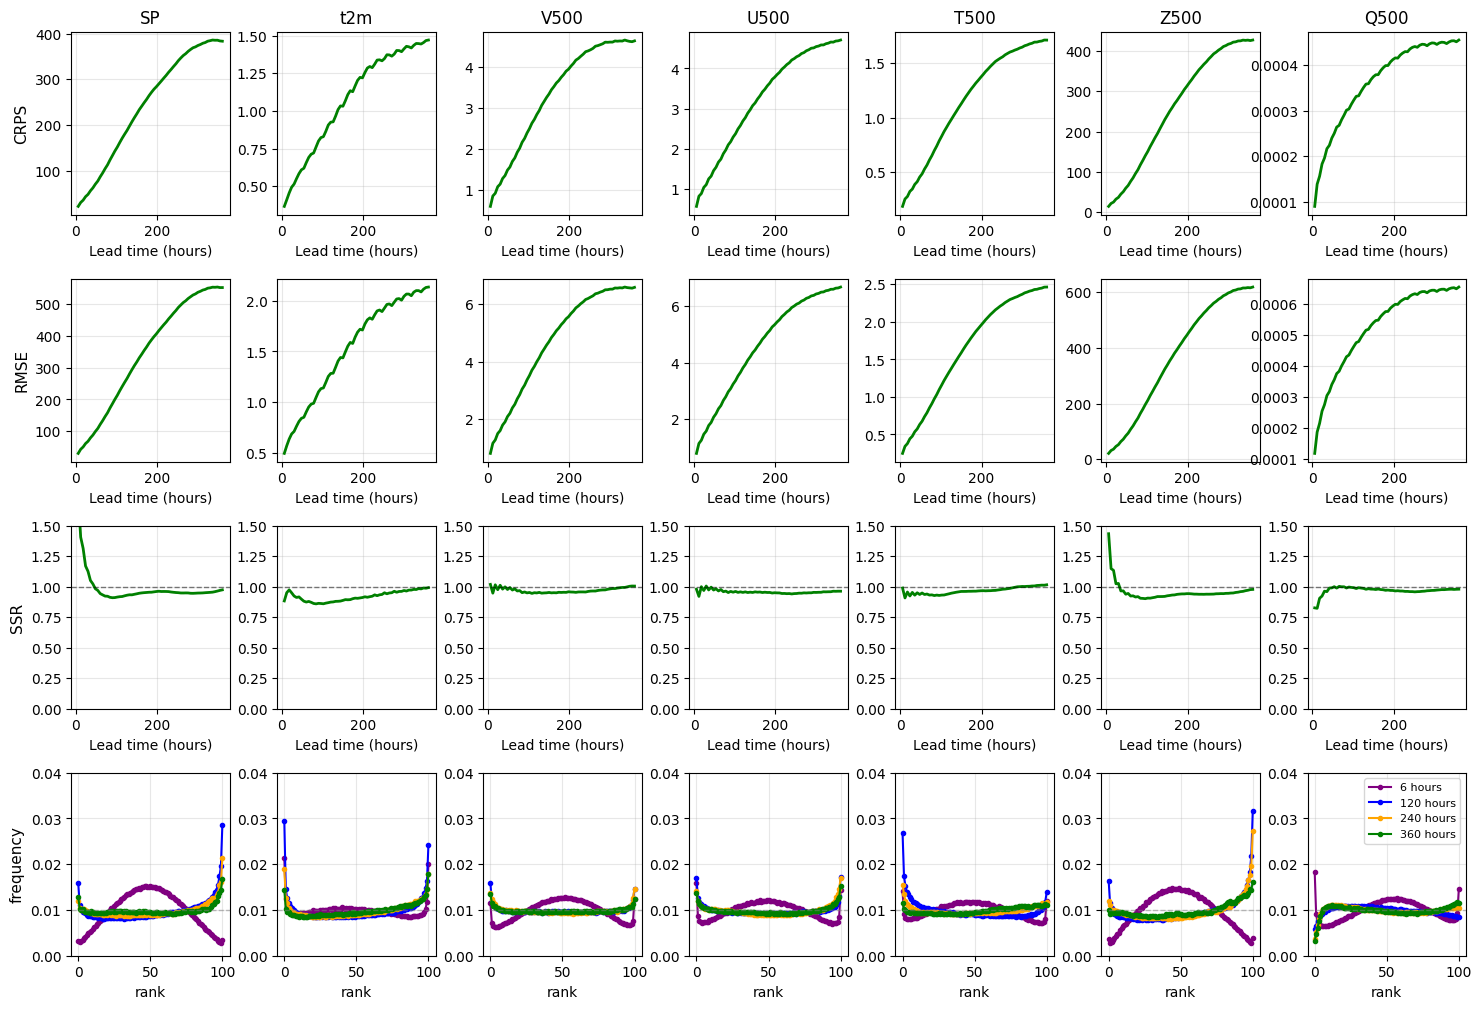

In [11]:
# Create plots for specific variables
variables_to_plot = ['SP', 't2m', 'V500', 'U500', 'T500', 'Z500', 'Q500']
plot_ensemble_metrics(aggregated, variables_to_plot, 'ensemble_metrics.png')
create_summary_statistics(aggregated, 'summary_stats.txt')